In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from plotly.offline import iplot
import plotly.express as px
import cufflinks as cf

In [2]:
df = pd.read_csv('../data/processed/llm_telemetry_v1_features_added_2026-05-26.csv')
df.head()

,model_name,input_tokens,output_tokens,latency_ms,status_code,gpu_cluster,hour_of_day,model_Claude-3,model_Claude-3-Opus,model_Gemini-1.5-Pro,...,model_Gpt-4,model_Gpt-4-Turbo,model_Gpt4,is_error,gpu_Unknown,gpu_aws-us-east,gpu_aws-us-west,gpu_azure-eu,gpu_gcp-asia,total_cost_used
0,Gpt-3.5-Turbo,1136,440,1492.41,200,gcp-asia,6,0,0,0,...,0,0,0,0,0,0,0,0,1,0.02456
1,Gemini_1.5,340,463,1211.95,429,Unknown,4,0,0,0,...,0,0,0,1,1,0,0,0,0,0.01729
2,Gemini-1.5-Pro,1133,876,2389.46,200,gcp-asia,20,0,0,1,...,0,0,0,0,0,0,0,0,1,0.03761
3,Gpt-4,469,318,944.24,200,gcp-asia,2,0,0,0,...,1,0,0,0,0,0,0,0,1,0.01423
4,Gpt-4,757,861,2241.32,200,aws-us-west,19,0,0,0,...,1,0,0,0,0,0,1,0,0,0.03340


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   model_name            1030 non-null   str    
 1   input_tokens          1030 non-null   int64  
 2   output_tokens         1030 non-null   int64  
 3   latency_ms            1030 non-null   float64
 4   status_code           1030 non-null   int64  
 5   gpu_cluster           1030 non-null   str    
 6   hour_of_day           1030 non-null   int64  
 7   model_Claude-3        1030 non-null   int64  
 8   model_Claude-3-Opus   1030 non-null   int64  
 9   model_Gemini-1.5-Pro  1030 non-null   int64  
 10  model_Gemini_1.5      1030 non-null   int64  
 11  model_Gpt-3.5-Turbo   1030 non-null   int64  
 12  model_Gpt-4           1030 non-null   int64  
 13  model_Gpt-4-Turbo     1030 non-null   int64  
 14  model_Gpt4            1030 non-null   int64  
 15  is_error              1030 non-n

In [4]:
df.shape

(1030, 22)

In [5]:
total_cost_per_hour = df.groupby('hour_of_day')['total_cost_used'].sum().reset_index()
total_req_per_hour  = df.groupby('hour_of_day')['input_tokens'].count().reset_index()



Provides a complete executive summary of hourly API load, latency, cost, and token usage.

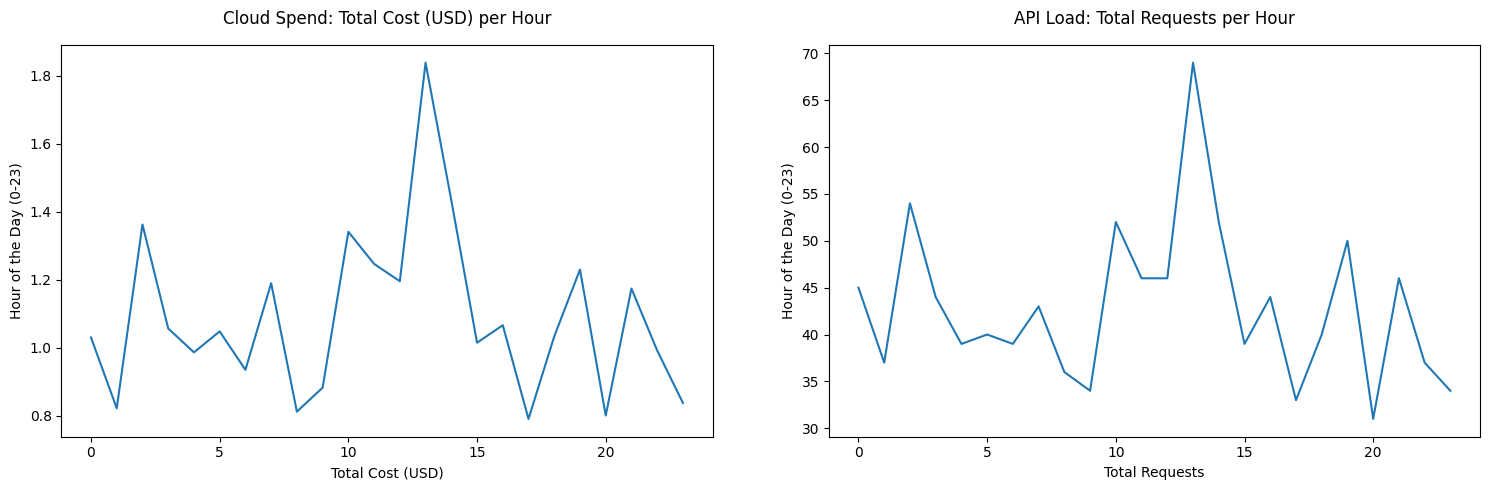

In [6]:
plt.figure(figsize=(15, 5))

plt.subplot(1,2,1)
plt.plot(total_cost_per_hour['hour_of_day'], total_cost_per_hour['total_cost_used'])
plt.title("Cloud Spend: Total Cost (USD) per Hour", pad=15)
plt.xlabel("Total Cost (USD)")
plt.ylabel("Hour of the Day (0-23)")

plt.subplot(1,2,2)
plt.plot(total_req_per_hour['hour_of_day'], total_req_per_hour['input_tokens'])
plt.title("API Load: Total Requests per Hour", pad= 15)
plt.xlabel("Total Requests")
plt.ylabel("Hour of the Day (0-23)")

plt.tight_layout(w_pad=5.0)

plt.savefig('../assets/plots/01_executive_summary_24h_trends.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
corr_matrix = df[['input_tokens', 'output_tokens', 'latency_ms', 'total_cost_used']]
corr_matrix.head()

,input_tokens,output_tokens,latency_ms,total_cost_used
0,1136,440,1492.41,0.02456
1,340,463,1211.95,0.01729
2,1133,876,2389.46,0.03761
3,469,318,944.24,0.01423
4,757,861,2241.32,0.03340


Proves the strong mathematical link between higher token counts, increased latency, and total cloud cost.

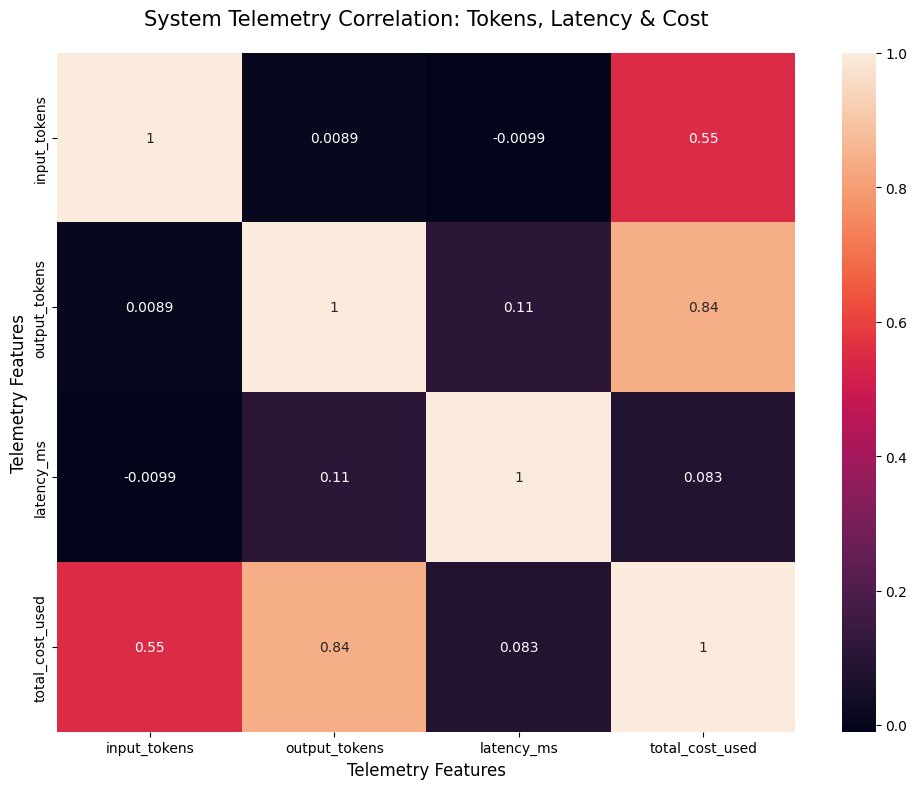

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix.corr(), annot= True)

plt.title("System Telemetry Correlation: Tokens, Latency & Cost", fontsize=15, pad=20) 
plt.xlabel("Telemetry Features", fontsize=12)
plt.ylabel("Telemetry Features", fontsize=12)
plt.tight_layout()


plt.savefig('../assets/plots/02_correlation_heatmap_telemetry.png', dpi=300, bbox_inches='tight')
plt.show()

Clearly isolates 500-level server errors as the root cause of massive latency spikes.

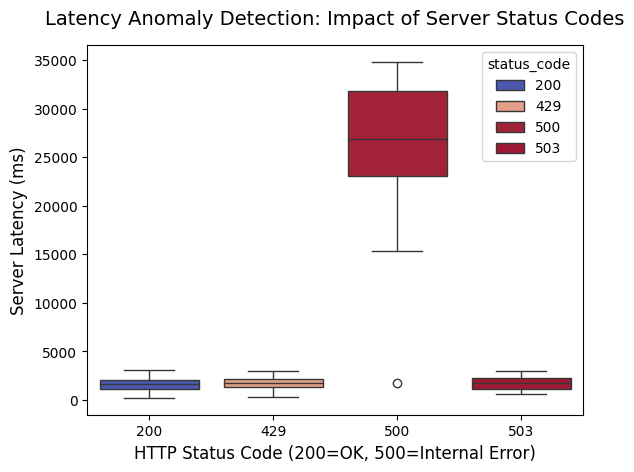

In [9]:
sns.boxplot(
          data= df,
          x= 'status_code',
          y= 'latency_ms',
          palette= 'coolwarm',
          hue= 'status_code'
)
plt.title("Latency Anomaly Detection: Impact of Server Status Codes", fontsize=14, pad=15)
plt.xlabel("HTTP Status Code (200=OK, 500=Internal Error)", fontsize=12)
plt.ylabel("Server Latency (ms)", fontsize=12)

plt.savefig('../assets/plots/03_latency_anomaly_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

Reveals that the majority of the API traffic consists of shorter input prompts.

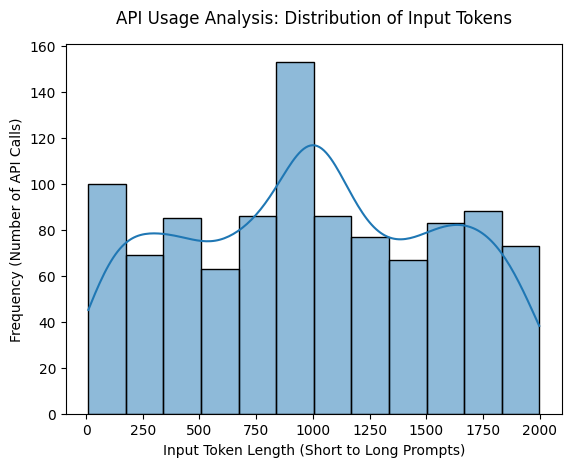

In [10]:
sns.histplot(
          data= df,
          x= 'input_tokens', 
          kde= True
     )
plt.title("API Usage Analysis: Distribution of Input Tokens", pad=15)
plt.xlabel("Input Token Length (Short to Long Prompts)")
plt.ylabel("Frequency (Number of API Calls)")

plt.savefig('../assets/plots/04_input_tokens_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

Statistically confirms the business trend that slower API responses result in higher operational costs.


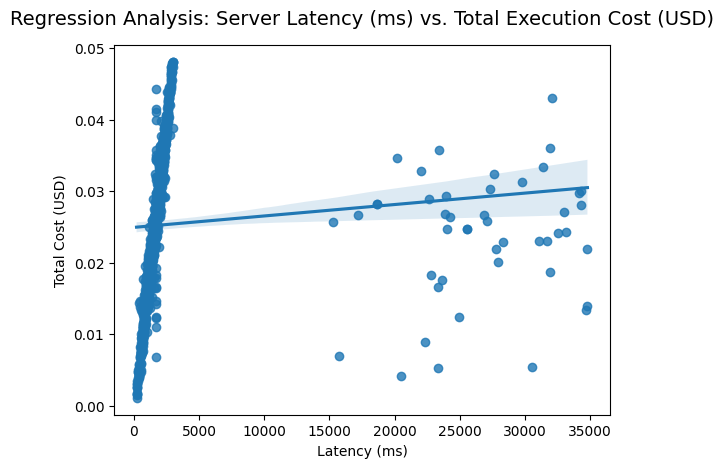

In [11]:
sns.regplot(
          data= df,
          x= 'latency_ms',
          y= 'total_cost_used'
     )

plt.title("Regression Analysis: Server Latency (ms) vs. Total Execution Cost (USD)", fontsize=14, pad=15)
plt.xlabel("Latency (ms)")
plt.ylabel("Total Cost (USD)")

plt.savefig('../assets/plots/05_cost_vs_latency_regression.png', dpi=300, bbox_inches='tight')
plt.show()

A multidimensional view showing how large tokens and high latency directly correlate with cost size and error rates.

In [12]:
fig= px.scatter(
          data_frame= df,
          x= 'input_tokens', 
          y= 'latency_ms', 
          size= 'total_cost_used', 
          color= 'is_error',
          title= 'Tokens vs Latency (Size=Cost, Color=Error)'
     )
fig.write_image('../assets/plots/06_3d_cost_latency_scatter.png', scale=2)
fig.show()

Pinpoints the exact hours of the day when the server experiences peak latency and stress.

In [13]:
hour_latency = df.groupby('hour_of_day')['latency_ms'].mean().reset_index()
hour_latency.head()

,hour_of_day,latency_ms
0,0,1478.472000
1,1,2739.159595
2,2,2616.453241
3,3,1987.590795
4,4,3876.982949


In [14]:
fig= px.line(
          data_frame= hour_latency,
          x= 'hour_of_day',
          y= 'latency_ms',
          title= 'Time-Series Anomaly: Average Server Latency per Hour',
          labels={'hour_of_day': 'Hour of the Day (0-23)', 'latency_ms': 'Average Latency (ms)'}
     )

fig.write_image('../assets/plots/07_time_series_latency_trends.png', scale=2)
fig.show()

Visualizes the global traffic distribution to show which cloud infrastructure region handles the maximum load.

In [15]:
fig= px.pie(
          data_frame= df,
          names= 'gpu_cluster',
          title="Cloud Infrastructure Load: Global GPU Cluster Distribution"
)

fig.write_image('../assets/plots/08_gpu_cluster_distribution.png', scale=2)
fig.show()